In [4]:
!pip install scikit-learn
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn

In [5]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# from google.colab import files
# uploaded = files.upload()

In [7]:
stats= pd.read_csv('MP2_Data.csv')

In [8]:
stats.head(2)

,ID,Week2_Quiz1,Week3_MP1,Week3_PR1,Week5_MP2,Week5_PR2,Week7_MP3,Week7_PR3,Week4_Quiz2,Week6_Quiz3,...,Week7_Stat3,Week8_Stat0,Week8_Stat1,Week8_Stat2,Week8_Stat3,Week9_Stat0,Week9_Stat1,Week9_Stat2,Week9_Stat3,Grade
0,ML-2020-1,5.00,15.0,5.0,16.09,5.0,21.88,5.0,5.0,5.0,...,0,5,4,0,4,8,6,1,0,4
1,ML-2020-2,3.33,15.0,5.0,17.83,5.0,22.27,5.0,4.0,5.0,...,8,5,2,0,0,25,3,2,5,4


# Step 1 - Data Preprocessing

In [9]:
# From the dataframe above, the ID column looks like it won't be crucial to this analsis. It's best to drop it at this point
stats.drop(columns=['ID'], inplace=True)

In [10]:
stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 47 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Week2_Quiz1  107 non-null    float64
 1   Week3_MP1    107 non-null    float64
 2   Week3_PR1    107 non-null    float64
 3   Week5_MP2    107 non-null    float64
 4   Week5_PR2    107 non-null    float64
 5   Week7_MP3    107 non-null    float64
 6   Week7_PR3    107 non-null    float64
 7   Week4_Quiz2  107 non-null    float64
 8   Week6_Quiz3  107 non-null    float64
 9   Week8_Total  107 non-null    float64
 10  Week1_Stat0  107 non-null    int64  
 11  Week1_Stat1  107 non-null    int64  
 12  Week1_Stat2  107 non-null    int64  
 13  Week1_Stat3  107 non-null    int64  
 14  Week2_Stat0  107 non-null    int64  
 15  Week2_Stat1  107 non-null    int64  
 16  Week2_Stat2  107 non-null    int64  
 17  Week2_Stat3  107 non-null    int64  
 18  Week3_Stat0  107 non-null    int64  
 19  Week3_St

In [11]:
#Note that Week1_Stat1 sums up to 0 for all records. I'll drop that column as it will not help the models that we will train
print(stats.sum())
stats.drop(columns=['Week1_Stat1'], inplace=True)
stats.head()

Week2_Quiz1     257.51
Week3_MP1       850.61
Week3_PR1       300.00
Week5_MP2       988.44
Week5_PR2       304.38
Week7_MP3      1549.56
Week7_PR3       255.00
Week4_Quiz2     279.21
Week6_Quiz3     285.00
Week8_Total    5069.71
Week1_Stat0     726.00
Week1_Stat1       0.00
Week1_Stat2      64.00
Week1_Stat3      24.00
Week2_Stat0    1807.00
Week2_Stat1    1423.00
Week2_Stat2     134.00
Week2_Stat3     197.00
Week3_Stat0    3395.00
Week3_Stat1     302.00
Week3_Stat2     102.00
Week3_Stat3     121.00
Week4_Stat0    4485.00
Week4_Stat1    1717.00
Week4_Stat2     208.00
Week4_Stat3     108.00
Week5_Stat0    2790.00
Week5_Stat1     536.00
Week5_Stat2     170.00
Week5_Stat3      71.00
Week6_Stat0    4024.00
Week6_Stat1    1527.00
Week6_Stat2     297.00
Week6_Stat3      44.00
Week7_Stat0    1750.00
Week7_Stat1     347.00
Week7_Stat2     194.00
Week7_Stat3     134.00
Week8_Stat0    1125.00
Week8_Stat1     335.00
Week8_Stat2     119.00
Week8_Stat3      38.00
Week9_Stat0     820.00
Week9_Stat1

,Week2_Quiz1,Week3_MP1,Week3_PR1,Week5_MP2,Week5_PR2,Week7_MP3,Week7_PR3,Week4_Quiz2,Week6_Quiz3,Week8_Total,...,Week7_Stat3,Week8_Stat0,Week8_Stat1,Week8_Stat2,Week8_Stat3,Week9_Stat0,Week9_Stat1,Week9_Stat2,Week9_Stat3,Grade
0,5.00,15.0,5.0,16.09,5.00,21.88,5.0,5.00,5.0,82.97,...,0,5,4,0,4,8,6,1,0,4
1,3.33,15.0,5.0,17.83,5.00,22.27,5.0,4.00,5.0,82.43,...,8,5,2,0,0,25,3,2,5,4
2,1.67,13.0,5.0,15.22,5.00,27.05,2.5,5.00,5.0,79.44,...,0,8,2,0,0,9,0,1,0,3
3,2.50,14.0,5.0,10.00,5.00,31.02,5.0,3.13,5.0,80.65,...,4,10,0,0,0,7,6,0,0,3
4,0.00,15.0,5.0,12.17,4.93,15.91,5.0,4.67,5.0,67.68,...,6,8,5,1,1,5,3,1,0,2


In [12]:
stats.describe()

,Week2_Quiz1,Week3_MP1,Week3_PR1,Week5_MP2,Week5_PR2,Week7_MP3,Week7_PR3,Week4_Quiz2,Week6_Quiz3,Week8_Total,...,Week7_Stat3,Week8_Stat0,Week8_Stat1,Week8_Stat2,Week8_Stat3,Week9_Stat0,Week9_Stat1,Week9_Stat2,Week9_Stat3,Grade
count,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,...,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000
mean,2.406636,7.949626,2.803738,9.237757,2.844673,14.481869,2.383178,2.609439,2.663551,47.380467,...,1.252336,10.514019,3.130841,1.112150,0.355140,7.663551,1.607477,1.093458,0.046729,2.074766
std,2.000317,6.892312,2.493158,8.640610,2.482099,14.080211,2.437501,2.229419,2.414359,41.035589,...,2.399267,15.563846,4.841028,3.658351,1.191577,9.277630,2.687346,3.368928,0.483368,1.993863
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,3.330000,12.000000,5.000000,10.870000,5.000000,15.910000,2.500000,3.170000,4.000000,71.530000,...,0.000000,5.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,3.000000
75%,4.170000,14.305000,5.000000,18.045000,5.000000,27.440000,5.000000,4.710000,5.000000,83.550000,...,2.000000,14.000000,5.000000,0.000000,0.000000,11.000000,2.000000,0.500000,0.000000,4.000000
max,5.000000,15.000000,5.000000,20.000000,5.000000,35.000000,5.000000,5.000000,5.000000,99.710000,...,12.000000,90.000000,27.000000,22.000000,9.000000,62.000000,12.000000,25.000000,5.000000,5.000000


# EDA

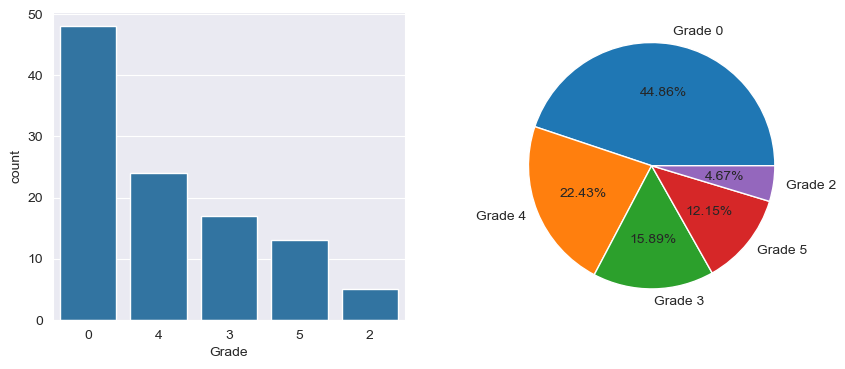

In [13]:
fig1, ax = plt.subplots(1,2, figsize=(10,4))
# count plot
sns.countplot(x='Grade', data=stats, order=stats['Grade'].value_counts().index, ax=ax[0])
# pie chart
ax[1]=plt.pie(stats['Grade'].value_counts(),
            autopct='%1.2f%%', labels=['Grade 0', 'Grade 4', 'Grade 3', 'Grade 5', 'Grade 2'])
plt.show()

From the graphs above, it can be seen that a lot of students failed the course(got grade O), about 50  students out of the 107. T

In [14]:
#Finding the correlation between all features and our target 'Grade'
stats.corr(numeric_only=True)

,Week2_Quiz1,Week3_MP1,Week3_PR1,Week5_MP2,Week5_PR2,Week7_MP3,Week7_PR3,Week4_Quiz2,Week6_Quiz3,Week8_Total,...,Week7_Stat3,Week8_Stat0,Week8_Stat1,Week8_Stat2,Week8_Stat3,Week9_Stat0,Week9_Stat1,Week9_Stat2,Week9_Stat3,Grade
Week2_Quiz1,1.000000,0.739992,0.723109,0.677371,0.710990,0.635804,0.622655,0.746331,0.695119,0.739192,...,0.391529,0.390792,0.429210,0.018500,0.235174,0.472536,0.436145,0.213437,0.045046,0.689783
Week3_MP1,0.739992,1.000000,0.962502,0.905769,0.964849,0.881352,0.834397,0.879998,0.912700,0.965074,...,0.455459,0.477576,0.541086,0.037039,0.268698,0.549969,0.518334,0.154754,0.099824,0.901788
Week3_PR1,0.723109,0.962502,1.000000,0.890706,0.942896,0.868638,0.830599,0.904170,0.906560,0.952095,...,0.456261,0.403779,0.500834,0.022088,0.185638,0.561184,0.489662,0.170683,0.085965,0.887352
Week5_MP2,0.677371,0.905769,0.890706,1.000000,0.932880,0.904458,0.874247,0.808479,0.847296,0.962302,...,0.474257,0.509593,0.559422,0.032855,0.204243,0.581338,0.455110,0.149925,0.097039,0.953488
Week5_PR2,0.710990,0.964849,0.942896,0.932880,1.000000,0.897020,0.854744,0.863713,0.887432,0.968613,...,0.447560,0.520521,0.554598,0.037541,0.245074,0.549798,0.522180,0.165532,0.084738,0.907837
Week7_MP3,0.635804,0.881352,0.868638,0.904458,0.897020,1.000000,0.807097,0.781677,0.814492,0.957955,...,0.355063,0.429833,0.578306,-0.027907,0.225299,0.480964,0.503761,0.099568,0.053977,0.968130
Week7_PR3,0.622655,0.834397,0.830599,0.874247,0.854744,0.807097,1.000000,0.785238,0.814822,0.883680,...,0.480963,0.455430,0.498989,0.017352,0.274266,0.570810,0.569017,0.190900,0.104765,0.865616
Week4_Quiz2,0.746331,0.879998,0.904170,0.808479,0.863713,0.781677,0.785238,1.000000,0.912396,0.884461,...,0.406047,0.414378,0.491858,-0.003162,0.258997,0.480060,0.418012,0.157015,0.060867,0.810920
Week6_Quiz3,0.695119,0.912700,0.906560,0.847296,0.887432,0.814492,0.814822,0.912396,1.000000,0.910623,...,0.388557,0.420776,0.501814,0.028878,0.274749,0.495457,0.452735,0.173820,0.094437,0.849920
Week8_Total,0.739192,0.965074,0.952095,0.962302,0.968613,0.957955,0.883680,0.884461,0.910623,1.000000,...,0.445558,0.484388,0.577887,0.010636,0.249535,0.559333,0.521482,0.152608,0.083350,0.972348


In [15]:
#The grades in the given data set are 0,2,3,4,5, for some reason there's no Grade 1 given in the dataset
stats['Grade'].unique()

array([4, 3, 2, 0, 5], dtype=int64)

In [16]:
#Intuitively, it is very unlikely that a student's grades will be affected by how much or how little active they are on the platform (i.e posting on forums, viewing profiles etc.)

#On the other hand, Quizzes, Labs, and Peer Reviews will directly affect the grade a student receives, therefore a list of good features to choose would be. This
# is confirmed by the correlation above
selected_features = ['Week3_MP1','Week5_MP2', 'Week7_MP3','Week3_PR1','Week5_PR2','Week7_PR3', 'Week6_Quiz3', 'Week4_Quiz2','Week2_Quiz1']
# selected_features = ['Week5_MP2', 'Week7_MP3', 'Week6_Quiz3', 'Week4_Quiz2','Week2_Quiz1', 'Week3_MP1']

C:\Users\agbec\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 40.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\agbec\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 29.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\agbec\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 30.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\agbec\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 72.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\agbec\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 66.4% of the points

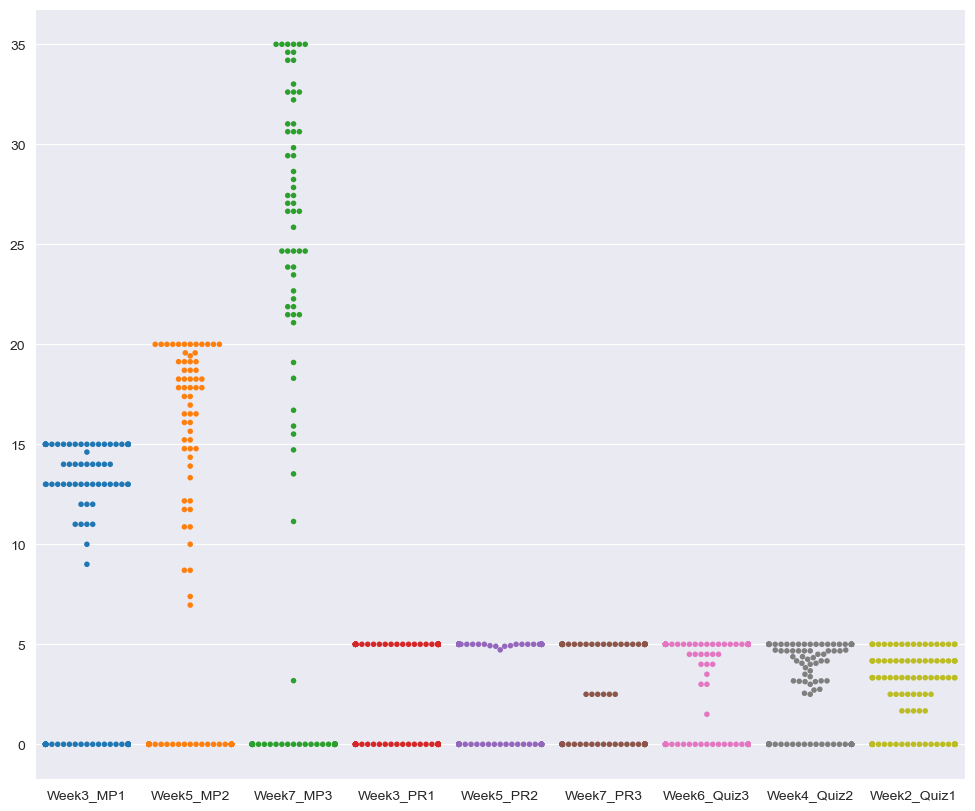

In [17]:

plt.figure(figsize=(12,10))
sns.swarmplot(data=stats[selected_features],size=4)
plt.show()

<Axes: >

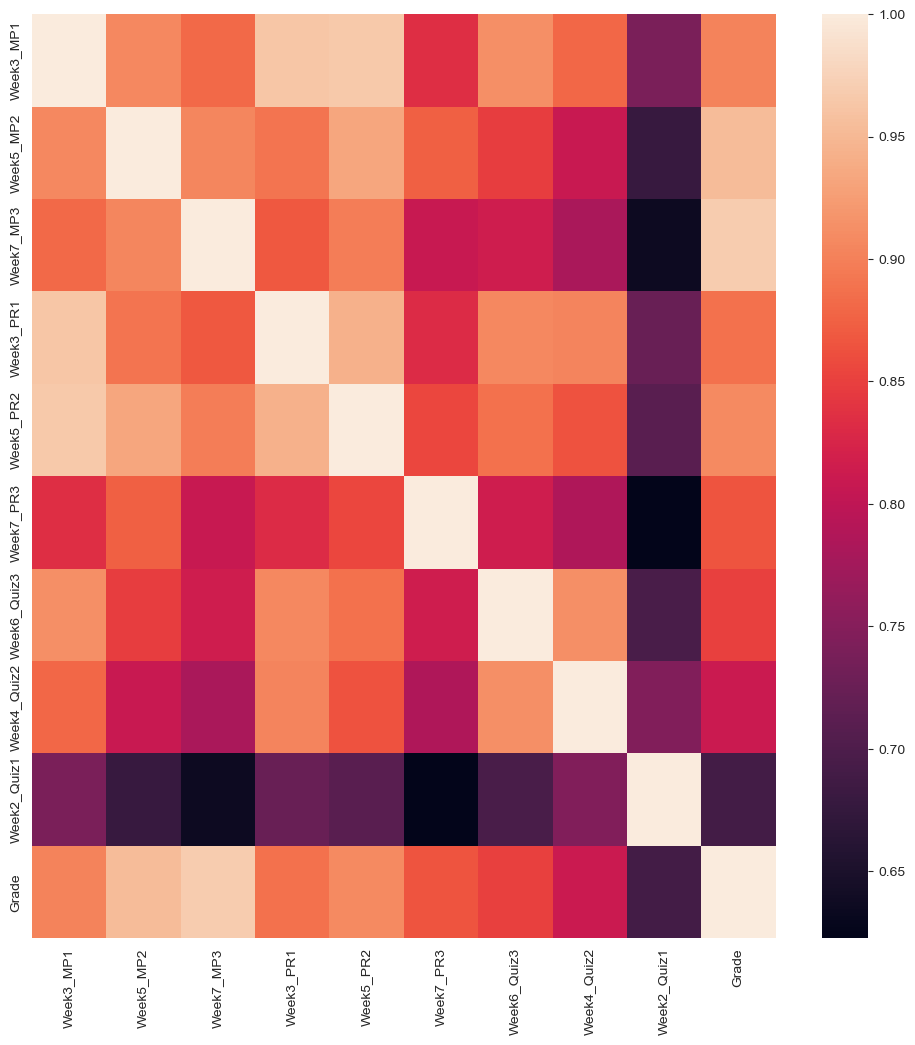

In [18]:
#After choosing the features to be used in the model training, I ran another correlation check on those features and the grade to get a good visualization
#on how correlated they are to the target(Grade)
plt.figure(figsize=(12,12))
sns.heatmap(stats[selected_features+['Grade']].corr(numeric_only=True), annot=False)

#### Explanation of swarmplot
1. To begin with, all of the selected features unfortunately have a lot of zeros in them. This can be a good explanation for why 44.86% of students failed the course.

2. All Peer reviews and Quizzes were scored out of a maximum of 5, and it can be seen that Peer Reviews were mostly either 0 or a 5, for the most part. This is not good and may cause bias in the model, it might be better to remove Peer Reviews from the selected features.

3. For the miniprojects, Mini project 3 shows promising variance, with students scoring all sorts of marks but slightly biased to the higher marks, as fewer students scored less than 20.

In [19]:

print(selected_features)

['Week3_MP1', 'Week5_MP2', 'Week7_MP3', 'Week3_PR1', 'Week5_PR2', 'Week7_PR3', 'Week6_Quiz3', 'Week4_Quiz2', 'Week2_Quiz1']


# Step 2 - Data split: Training and Test sets

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [21]:
# Helper functions


def scale_dataset(X_train, X_test):
  """
  Scales the training and testing datasets using StandardScaler.

  Args:
    X_train: The training dataset features.
    X_test: The testing dataset features.

  Returns:
    A tuple containing the scaled training and testing datasets.
  """
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)
  return X_train_scaled, X_test_scaled

def train_models(model,X_train, X_test, y_train):
  """
  Trains and evaluates several classification models.

  Args:
    model: The classification model to be trained.
    X_train: The training dataset features.
    X_test: The testing dataset features.
    y_train: The training dataset target variable

  Returns:
    The prediction of the trained model.
  """
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)


  return y_pred


In [22]:
#Dividing the dataset into selected features and targets
X = stats[selected_features]
y = stats['Grade']

#Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

X.head()

,Week3_MP1,Week5_MP2,Week7_MP3,Week3_PR1,Week5_PR2,Week7_PR3,Week6_Quiz3,Week4_Quiz2,Week2_Quiz1
0,15.0,16.09,21.88,5.0,5.00,5.0,5.0,5.00,5.00
1,15.0,17.83,22.27,5.0,5.00,5.0,5.0,4.00,3.33
2,13.0,15.22,27.05,5.0,5.00,2.5,5.0,5.00,1.67
3,14.0,10.00,31.02,5.0,5.00,5.0,5.0,3.13,2.50
4,15.0,12.17,15.91,5.0,4.93,5.0,5.0,4.67,0.00


In [23]:
#Scale the dataset using the predefined helper function
X_train_scaled, X_test_scaled = scale_dataset(X_train, X_test)

# Step 3 - Model Training

## First Model = Logistic Regression

In [24]:

from sklearn.linear_model import LogisticRegression
# Train the model using Logistic Regression via the helper function defined above
lr = LogisticRegression()
lr_y_pred = train_models(lr,X_train_scaled, X_test_scaled, y_train)



# Second Model - K-Nearest Neighbors Classifier

In [25]:

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=7)
knn_y_pred = train_models(knn, X_train_scaled, X_test_scaled, y_train)

In [26]:
#Helper functions to help evaluate accuracy of the models
def evaluate_predictions(model,y_true, y_pred):
  """
  Evaluates the model's predictions and prints the results in a nice format.

  Args:
    y_true: The true target values.
    y_pred: The predicted target values.
  """
  accuracy = accuracy_score(y_true, y_pred)
  conf_matrix = confusion_matrix(y_true, y_pred)
  sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title(f'Confusion Matrix for {model.__class__.__name__}')
  plt.show()
  class_report = classification_report(y_true, y_pred)

  print(f"\nClassification Report for {model.__class__.__name__}:")
  print(class_report)
  print("Accuracy: {} %".format(round(accuracy*100,2)) )



# Step 4 - Performance Evaluation


## Evaluation for Logistic Regression

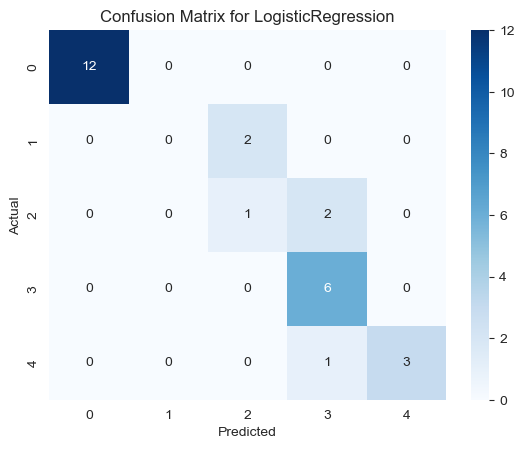


Classification Report for LogisticRegression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           2       0.00      0.00      0.00         2
           3       0.33      0.33      0.33         3
           4       0.67      1.00      0.80         6
           5       1.00      0.75      0.86         4

    accuracy                           0.81        27
   macro avg       0.60      0.62      0.60        27
weighted avg       0.78      0.81      0.79        27

Accuracy: 81.48 %


C:\Users\agbec\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\agbec\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\agbec\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
evaluate_predictions(lr,y_test, lr_y_pred)

## Evaluation for K-Nearest Neighbors Classifier

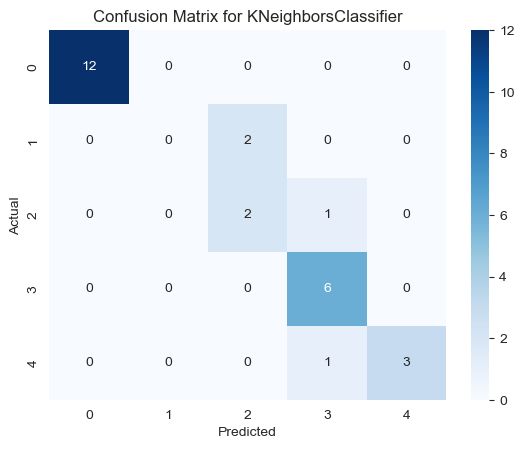


Classification Report for KNeighborsClassifier:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           2       0.00      0.00      0.00         2
           3       0.50      0.67      0.57         3
           4       0.75      1.00      0.86         6
           5       1.00      0.75      0.86         4

    accuracy                           0.85        27
   macro avg       0.65      0.68      0.66        27
weighted avg       0.81      0.85      0.83        27

Accuracy: 85.19 %


C:\Users\agbec\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\agbec\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\agbec\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
evaluate_predictions(knn,y_test, knn_y_pred)


### Trying to get a good performance for K-Nearest Neighbors

Text(0.5, 1.0, 'Error Rate vs K Values')

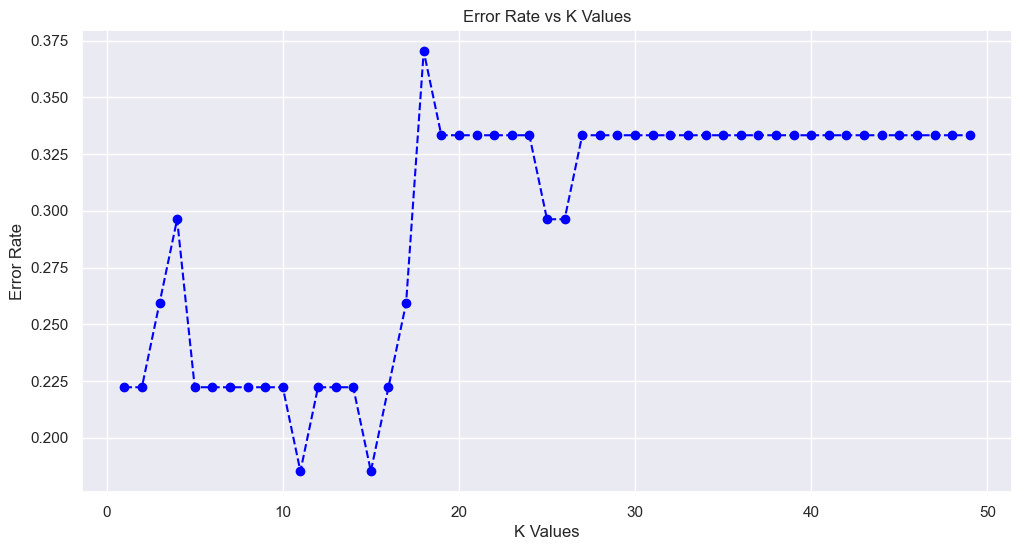

In [29]:
# 85% is not a bad performance but with KNN Classifiers we can also check for an optimal value of K using the elbow method below.
error_rate=[]
for i in range(1,50):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i!=y_test))
sns.set()
plt.figure(figsize=(12,6))
plt.plot(range(1,50),error_rate,color='blue',linestyle='--',marker='o')
plt.xlabel('K Values')
plt.ylabel('Error Rate')
plt.title('Error Rate vs K Values')

From the error rate graph, I typically want to select a value of
k that minimizes the error rate. In this case, values around k=5 k=7,k=10 seem to be good choices, as they show lower error rates compared to other values of k.
Even though k=11 and k=15 has the lowest points on the graph, they are not as stable as k>=5 and k<=10  .
k=5 shows stable performance with a slightly higher error but still low.
k=10 also has a stable and relatively low error rate.
To finalize the best k-value, it would be ideal to balance the error rate and avoid overfitting by not choosing too small of a k (like =k=1). Based on this graph, k=5 or k=7 or k=10 might work well for this K-Nearest Neighbors classifier.

## With that being said, I'll stick with k=7 for this KNeigborsClassifier

# Step 5 - Important features

       feature  importance
2    Week7_MP3    0.192593
1    Week5_MP2    0.162963
8  Week2_Quiz1    0.129630
7  Week4_Quiz2    0.092593
0    Week3_MP1    0.059259
5    Week7_PR3    0.059259
6  Week6_Quiz3    0.040741
3    Week3_PR1    0.029630
4    Week5_PR2   -0.018519


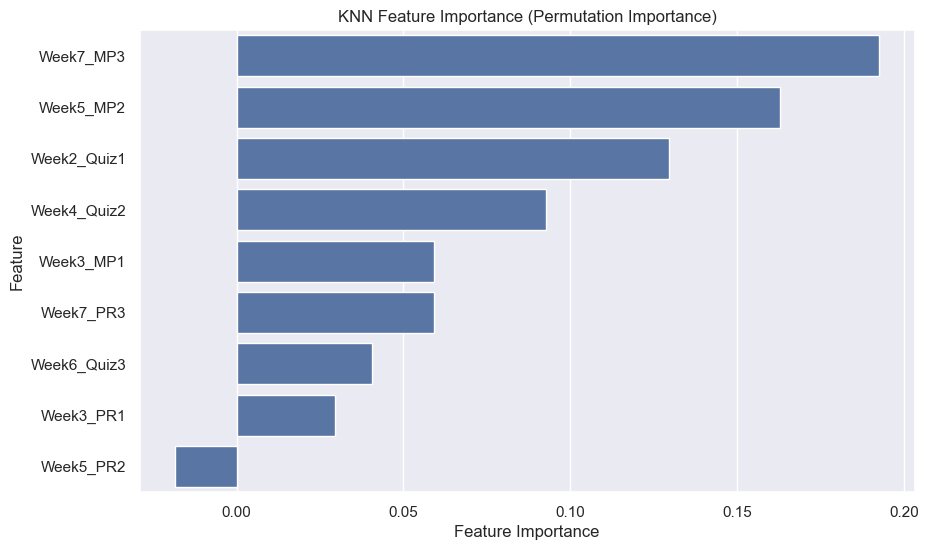

In [30]:

# KNN doesn't inherently provide feature importance like tree-based models.
# We can try to approximate it by looking at the influence of each feature on the model's predictions.
# One approach is to use permutation feature importance.

from sklearn.inspection import permutation_importance

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Perform permutation feature importance
result = permutation_importance(knn, X_test_scaled, y_test, n_repeats=10, random_state=42)

# Get feature importances
importances = result.importances_mean

# Create a DataFrame for easier visualization
feature_importance_df = pd.DataFrame({'feature': selected_features, 'importance': importances})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

# Display the feature importance
print(feature_importance_df)

# Visualize the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('KNN Feature Importance (Permutation Importance)')
plt.show()


Permutation feature importance is a model inspection technique that measures the contribution of each feature to a fitted model’s statistical performance on a given tabular dataset. This technique is particularly useful for non-linear or opaque estimators, and involves randomly shuffling the values of a single feature and observing the resulting degradation of the model’s score.

Taking the graph above, we can see that the third miniproject in Week 7 had the most influence on the predictive power of the model.

The second Peer Review in Week 5 on the other hand had a very poor influence on the model and would have been better of removed, as discussed in the cell where the swarmplot of the selected features was plotted.